In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [7]:
import pandas as pd

df = pd.read_csv("nba_games_2019_20_spurs_rockets_thunder.csv")

# Inspect data
df.head()

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna()

# Create win indicator
df["Win"] = df["WL"].apply(lambda x: 1 if x == "W" else 0)

# Convert date column
df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])

# Create home/away indicator
df["Home"] = df["MATCHUP"].apply(lambda x: 1 if "vs." in x else 0)

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,22019,1610612745,HOU,Houston Rockets,21901315,2020-08-14,HOU vs. PHI,L,240,96,...,0.875,1,26,27,25,10,9,17,18,-38.0
1,22019,1610612745,HOU,Houston Rockets,21901304,2020-08-12,HOU vs. IND,L,239,104,...,0.857,6,43,49,20,8,6,20,20,-4.0
2,22019,1610612745,HOU,Houston Rockets,21901298,2020-08-11,HOU @ SAS,L,240,105,...,0.905,4,33,37,18,14,3,18,19,-18.0
3,22019,1610612745,HOU,Houston Rockets,21901290,2020-08-09,HOU @ SAC,W,240,129,...,0.833,8,40,48,21,9,3,15,18,17.0
4,22019,1610612745,HOU,Houston Rockets,21901273,2020-08-06,HOU vs. LAL,W,238,113,...,0.870,4,30,34,26,11,5,19,28,16.0


In [3]:
team_means = df.groupby("TEAM_NAME")[["PTS", "REB", "AST", "TOV"]].mean()

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix of Key Performance Metrics')

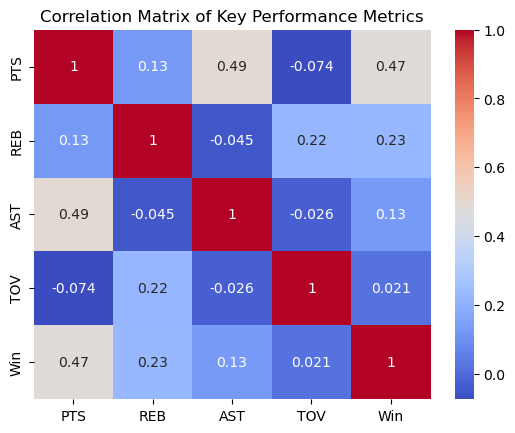

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[["PTS", "REB", "AST", "TOV", "Win"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Key Performance Metrics")
plt.show()

In [5]:
home_away = df.groupby(["TEAM_NAME", "Home"])["Win"].mean()

In [6]:
import statsmodels.api as sm

X = df[["PTS", "REB", "AST", "TOV"]]
y = df["Win"]

X = sm.add_constant(X)

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.527621
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    Win   No. Observations:                  215
Model:                          Logit   Df Residuals:                      210
Method:                           MLE   Df Model:                            4
Date:                Wed, 25 Feb 2026   Pseudo R-squ.:                  0.2313
Time:                        17:11:51   Log-Likelihood:                -113.44
converged:                       True   LL-Null:                       -147.57
Covariance Type:            nonrobust   LLR p-value:                 5.280e-14
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -15.3054      2.524     -6.065      0.000     -20.252     -10.359
PTS            0.1236      0.